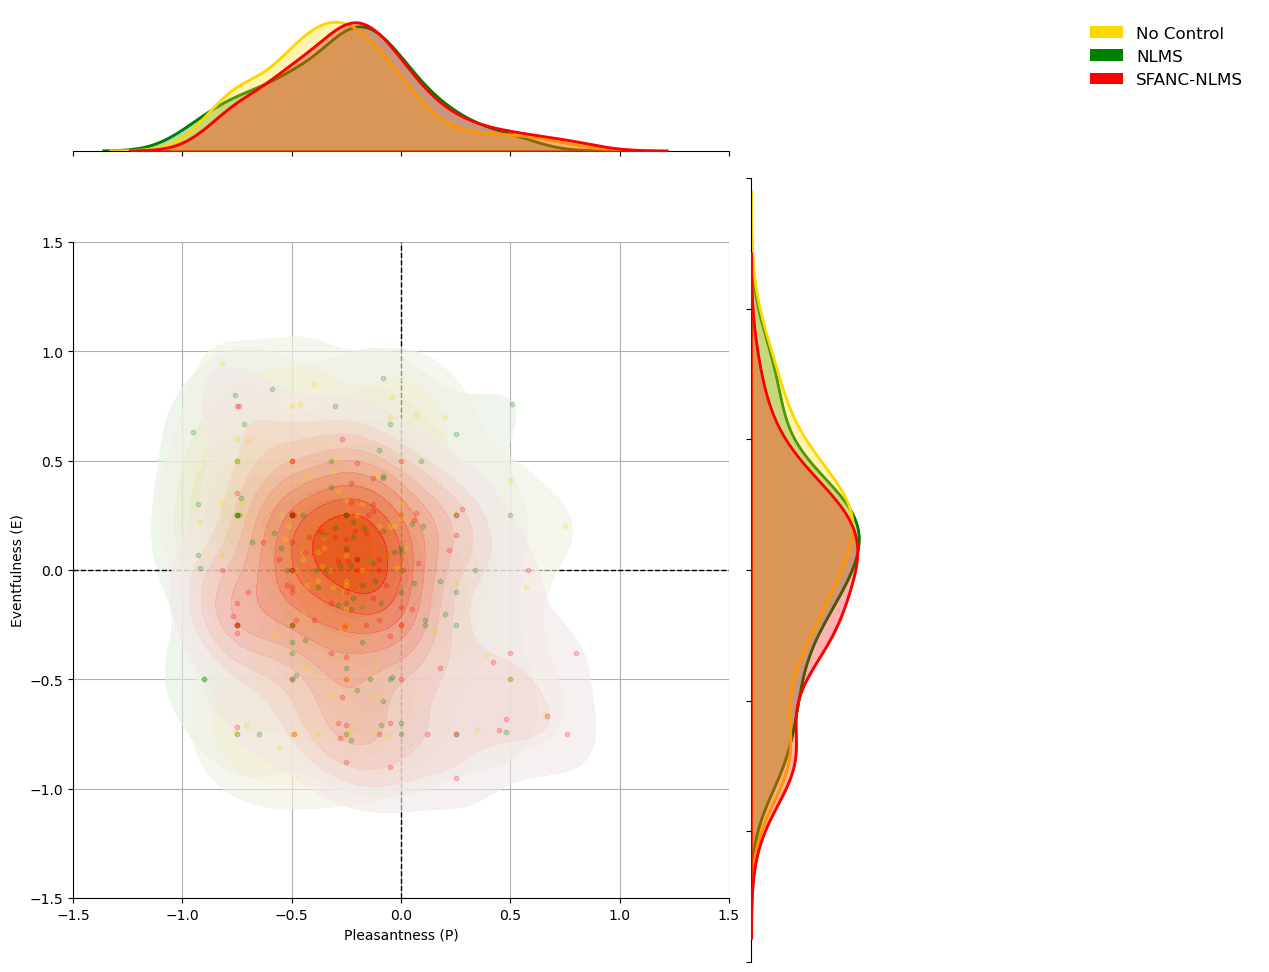

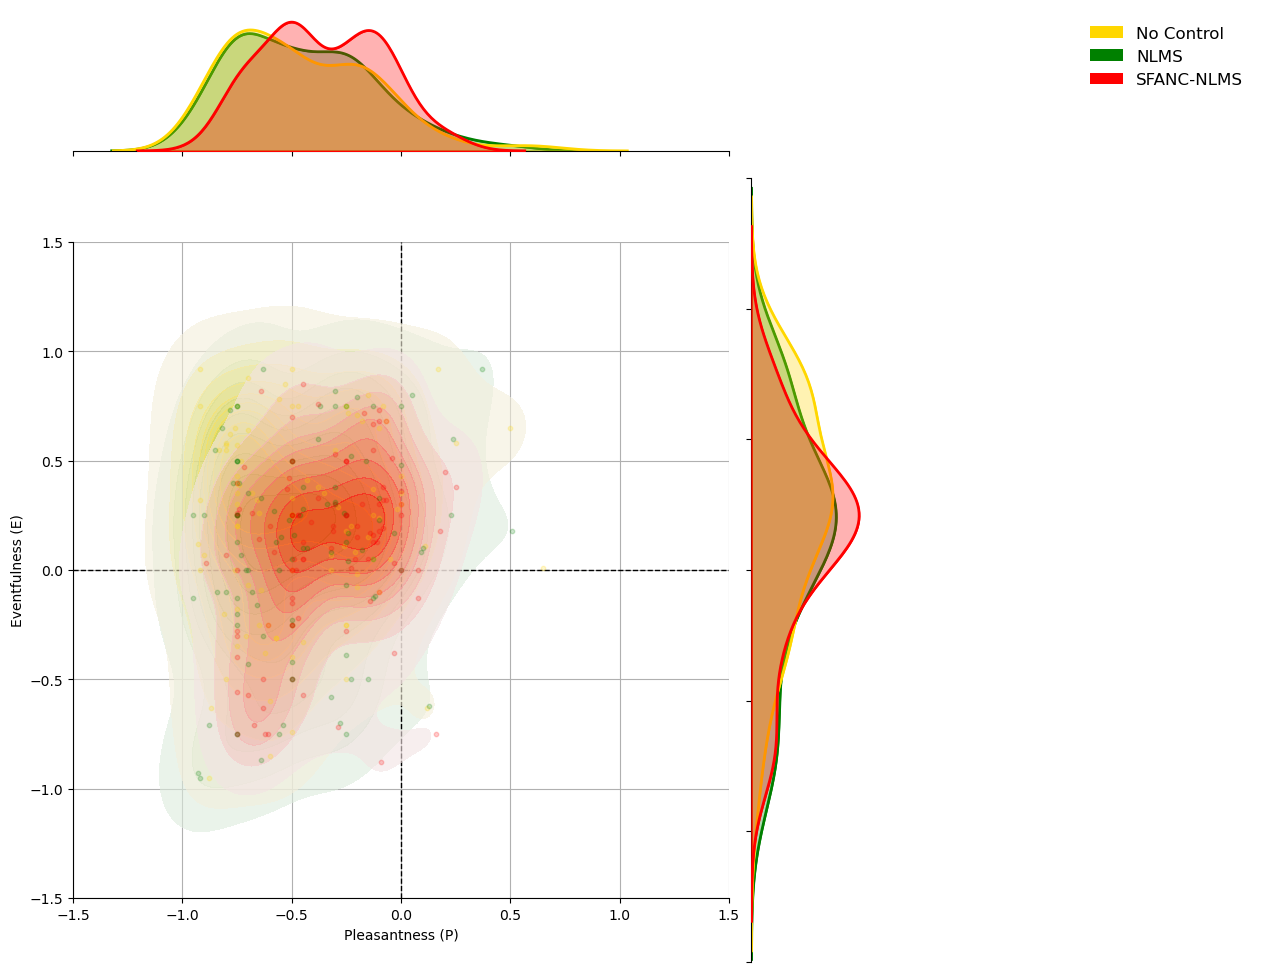

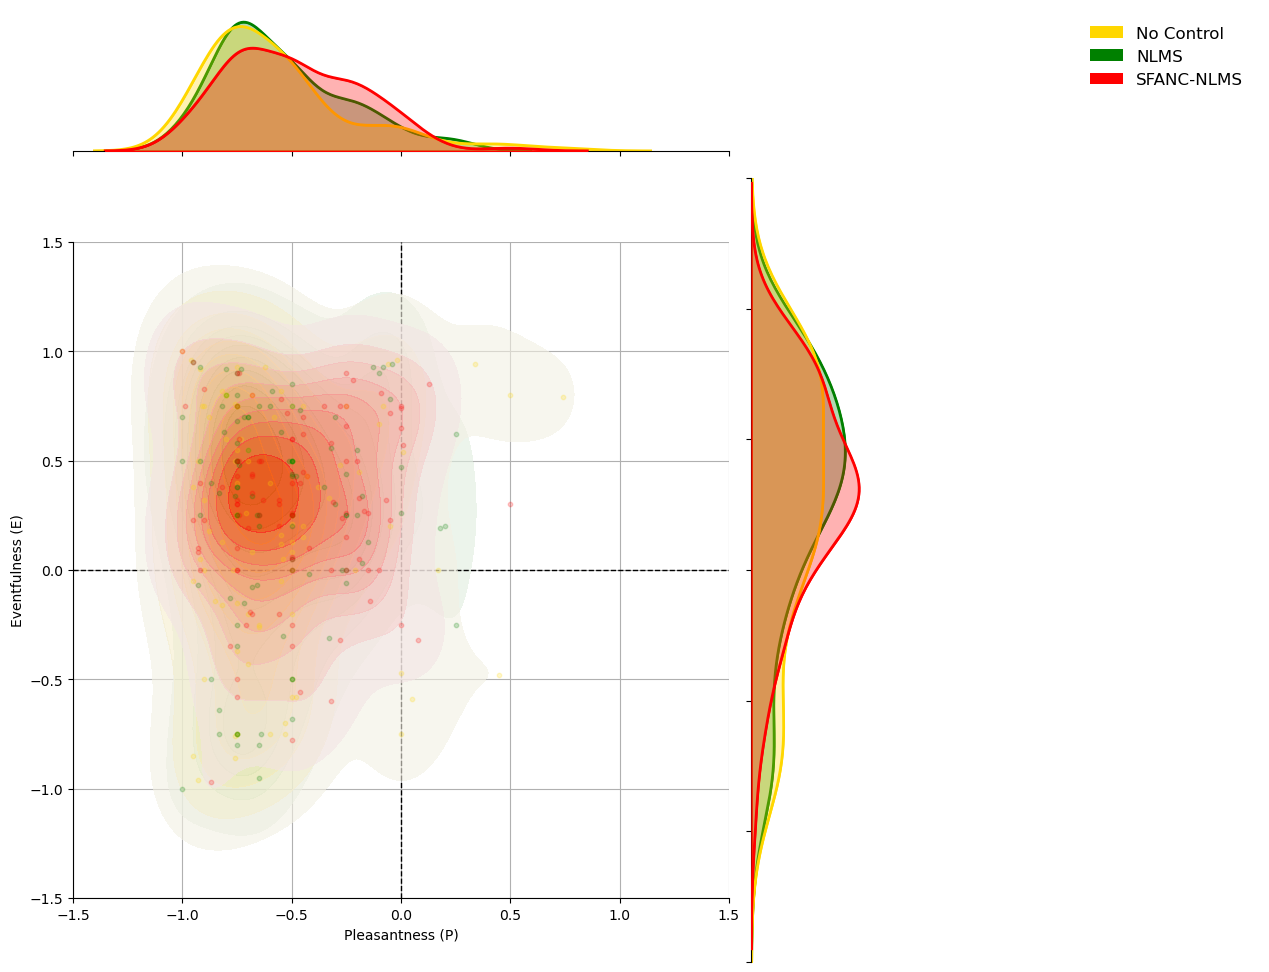

All figures saved successfully in the 'Figures' folder.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.patches import Patch
import os

# Load the data
stimuli_table = pd.read_csv(r'Stimuli_information.csv')
participant_data = pd.read_csv(r'PAQ_results.csv')

# Define noise levels
noise_levels = [55, 65, 72]

# Define colors for each control condition
control_colors = {
    'No Control': 'gold',              # Gold for No Control
    'Traditional Algorithm': 'green',  # Green for Traditional Algorithm
    'New Algorithm': 'red'             # Red for New Algorithm
}

# Create output folder if it does not exist
output_folder = 'Figures'
os.makedirs(output_folder, exist_ok=True)

for noise_level in noise_levels:
    # Create a JointGrid for each noise level
    g = sns.JointGrid(xlim=[-1.5, 1.5], ylim=[-1.5, 1.5], height=10, ratio=5)
    g.ax_joint.set_aspect('equal')
    
    # Store X and Y coordinates for each condition
    all_x = {'No Control': [], 'Traditional Algorithm': [], 'New Algorithm': []}
    all_y = {'No Control': [], 'Traditional Algorithm': [], 'New Algorithm': []}
    noise_condition = stimuli_table[stimuli_table['Noise_Level'] == noise_level]
    
    for control_condition in control_colors.keys():
        condition_stimuli = noise_condition[noise_condition['Control_Condition'] == control_condition]
        for j in range(condition_stimuli.shape[0]):
            stimulus_name = condition_stimuli['Stimuli'].iloc[j]
            stimulus_idx = np.where(stimuli_table['Stimuli'] == stimulus_name)[0][0]
            x = participant_data.iloc[:, 2 * stimulus_idx + 1].to_numpy()
            y = participant_data.iloc[:, 2 * stimulus_idx + 2].to_numpy()
            valid_indices = np.isfinite(x) & np.isfinite(y)
            all_x[control_condition].extend(x[valid_indices])
            all_y[control_condition].extend(y[valid_indices])
    
    # Plot scatter points with reduced opacity (to highlight density areas)
    for control_condition in control_colors.keys():
        g.ax_joint.scatter(all_x[control_condition], all_y[control_condition],
                           label=control_condition, alpha=0.2, s=10,
                           color=control_colors[control_condition], zorder=5)
    
    # Marginal densities on the X axis
    # Plot Traditional (green) first, then No Control (gold)
    sns.kdeplot(x=all_x['Traditional Algorithm'], ax=g.ax_marg_x, fill=True,
                color=control_colors['Traditional Algorithm'], alpha=0.3, zorder=1)
    sns.kdeplot(x=all_x['Traditional Algorithm'], ax=g.ax_marg_x,
                color=control_colors['Traditional Algorithm'], alpha=1, lw=2, zorder=1)
    
    sns.kdeplot(x=all_x['No Control'], ax=g.ax_marg_x, fill=True,
                color=control_colors['No Control'], alpha=0.3, zorder=2)
    sns.kdeplot(x=all_x['No Control'], ax=g.ax_marg_x,
                color=control_colors['No Control'], alpha=1, lw=2, zorder=2)
    
    # Finally, plot New Algorithm (red) so it appears on top
    sns.kdeplot(x=all_x['New Algorithm'], ax=g.ax_marg_x, fill=True,
                color=control_colors['New Algorithm'], alpha=0.3, zorder=3)
    sns.kdeplot(x=all_x['New Algorithm'], ax=g.ax_marg_x,
                color=control_colors['New Algorithm'], alpha=1, lw=2, zorder=3)
    
    # Marginal densities on the Y axis (same order)
    sns.kdeplot(y=all_y['Traditional Algorithm'], ax=g.ax_marg_y, fill=True,
                color=control_colors['Traditional Algorithm'], alpha=0.3, zorder=1)
    sns.kdeplot(y=all_y['Traditional Algorithm'], ax=g.ax_marg_y,
                color=control_colors['Traditional Algorithm'], alpha=1, lw=2, zorder=1)
    
    sns.kdeplot(y=all_y['No Control'], ax=g.ax_marg_y, fill=True,
                color=control_colors['No Control'], alpha=0.3, zorder=2)
    sns.kdeplot(y=all_y['No Control'], ax=g.ax_marg_y,
                color=control_colors['No Control'], alpha=1, lw=2, zorder=2)
    
    sns.kdeplot(y=all_y['New Algorithm'], ax=g.ax_marg_y, fill=True,
                color=control_colors['New Algorithm'], alpha=0.3, zorder=3)
    sns.kdeplot(y=all_y['New Algorithm'], ax=g.ax_marg_y,
                color=control_colors['New Algorithm'], alpha=1, lw=2, zorder=3)
    
    # On the main plot, draw density areas for each condition
    # Plot Traditional and No Control first, then New Algorithm (red) on top
    sns.kdeplot(x=all_x['Traditional Algorithm'], y=all_y['Traditional Algorithm'], ax=g.ax_joint,
                color=control_colors['Traditional Algorithm'], fill=True, alpha=0.6,
                levels=10, thresh=0.05,
                cmap=sns.light_palette(control_colors['Traditional Algorithm'], as_cmap=True),
                zorder=2)
    
    sns.kdeplot(x=all_x['No Control'], y=all_y['No Control'], ax=g.ax_joint,
                color=control_colors['No Control'], fill=True, alpha=0.6,
                levels=10, thresh=0.05,
                cmap=sns.light_palette(control_colors['No Control'], as_cmap=True),
                zorder=3)
    
    sns.kdeplot(x=all_x['New Algorithm'], y=all_y['New Algorithm'], ax=g.ax_joint,
                color=control_colors['New Algorithm'], fill=True, alpha=0.6,
                levels=10, thresh=0.05,
                cmap=sns.light_palette(control_colors['New Algorithm'], as_cmap=True),
                zorder=4)
    
    # Configure axes and title
    g.set_axis_labels("Pleasantness (P)", "Eventfulness (E)")
    g.ax_joint.grid(True)
    g.ax_joint.axhline(0, color='k', linestyle='--', linewidth=1.0)
    g.ax_joint.axvline(0, color='k', linestyle='--', linewidth=1.0)
    #g.fig.suptitle(f'Noise Level: {noise_level} dB(A)', y=1.03, fontsize=16)
    
    # Legend
    legend_elements = [
        Patch(facecolor='gold', label='No Control'),
        Patch(facecolor='green', label='NLMS'),
        Patch(facecolor='red', label='SFANC-NLMS')
    ]
    g.fig.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.05, 1),
                 fontsize=12, borderpad=1, handlelength=2, frameon=False)
    plt.subplots_adjust(right=0.85)
    
    # Save and display the figure
    output_filename = f'{output_folder}/{noise_level}dB_map.pdf'
    plt.savefig(output_filename, format='pdf', bbox_inches='tight')
    plt.show()

print("All figures saved successfully in the 'Figures' folder.")
